<a href="https://colab.research.google.com/github/HarithaGottumukkala/data266-1598/blob/main/neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 266 - Homework 1

## 0.1 Personal Parameters

For this homework, the personal parameters are calculated using the last four digits of my SJSU student ID. These values will be used throughout the assignment for reproducibility and for selecting the modified neural network configuration.

My SID4 is 1598. I calculate SEED, SLICE, HP_ID, CLS_A, and CLS_B using the formulas given in the assignment.

In [ ]:
# My homework parameters

SID4 = 1598

SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6

CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

print("SID4 =", SID4)
print("SEED =", SEED)
print("SLICE =", SLICE)
print("HP_ID =", HP_ID)
print("CLS_A =", CLS_A)
print("CLS_B =", CLS_B)

SID4 = 1598
SEED = 1598
SLICE = 598
HP_ID = 2
CLS_A = 8
CLS_B = 5


### Observation

The calculated HP_ID is 2. According to the HW1 configuration table, my modified neural network will keep the same hidden layers [64, 32] and 30 epochs as the baseline model, but the learning rate will be increased from 0.001 to 0.003.

This means that later in the assignment I will mainly study how increasing the learning rate affects the training behavior and test performance.

## 0.2 Reproducibility

To make my experiments reproducible, I will use the assigned SEED value for Python, NumPy, PyTorch, and TensorFlow.

Using the same seed helps keep random operations such as model initialization and data splitting consistent. The dataset split will later use `random_state = SEED`, while model training will also be repeated with SEED, SEED+1, and SEED+2 as required in the assignment.

In [ ]:
# Setting random seeds for reproducibility

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import tensorflow as tf

from sklearn.model_selection import train_test_split

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("SEED used =", SEED)
print("CUDA available =", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU =", torch.cuda.get_device_name(0))

SEED used = 1598
CUDA available = True
GPU = Tesla T4


### Observation

The reproducibility setup uses my assigned SEED value of 1598 for Python, NumPy, PyTorch, and TensorFlow. The current Colab runtime also has CUDA enabled and is using a Tesla T4 GPU. I will keep the dataset split fixed using `random_state = SEED` and later repeat the model training using SEED, SEED+1, and SEED+2 as required.

# 1 .What are autoregressive models? Provide real-world examples.

# 1. Autoregressive Models

An autoregressive model is a model that uses previous values to predict the next value.

The basic idea is actually simple. If we want to know what might happen next, we look at what happened before. The model learns the pattern from the previous values and then uses that pattern to make the next prediction.

For example, suppose the temperatures for the last few days were:

70°F, 72°F, 74°F, 75°F

An autoregressive model can use these previous temperature values to estimate the temperature for the next day.

The same idea can be used in many real-world situations.

### Weather Forecasting

One example is weather forecasting. Temperatures from previous days can be used to help predict the temperature for the next day. Recent weather conditions usually give some useful information about what may happen next.

### Sales Prediction

Autoregressive models can also be useful for sales forecasting. For example, a store can look at its sales from the previous few weeks and use that information to estimate the sales for the coming week.

### Stock Market Data

Past stock prices or returns can also be used to try to predict future values. However, stock prices depend on many other things such as news, company performance, and the economy, so previous values alone may not always give an accurate prediction.

### Text Generation

Autoregressive models are also used for generating text. A model looks at the words that have already been written and predicts what word may come next.

For example, if the sentence is:

"I am going to the..."

the next word could be "store", "school", or "office".

After predicting one word, that word becomes part of the input and the model continues predicting the next word.

### Speech and Audio

A similar idea can be used with audio. Previous sound values can be used to predict the next sound value. Repeating this process can help generate speech or other audio sequences.

### Conclusion

So, in simple terms, an autoregressive model learns from previous values in a sequence and uses them to predict what comes next. It is useful in areas such as weather forecasting, sales prediction, financial data, text generation, and audio generation.

# 2. Diabetes Dataset - Neural Network Implementation

In this part of the assignment, I will use the provided diabetes dataset to build and compare feedforward neural networks using PyTorch and TensorFlow.

Before training the models, I will first load and inspect the dataset, preprocess the data, visualize the feature relationships and distributions, and then create the required training, validation, and testing splits.

## 2.1 Loading the Dataset

First, I will load the diabetes dataset using Pandas. Before doing any preprocessing or building the neural network, I want to inspect the dataset and understand its structure, columns, and values.

In [ ]:
import pandas as pd

# The given CSV file does not have column headers
df = pd.read_csv("/content/diabetes.csv", header=None)

# Adding simple names so the columns are easier to use
df.columns = [
    "Feature_1",
    "Feature_2",
    "Feature_3",
    "Feature_4",
    "Feature_5",
    "Feature_6",
    "Feature_7",
    "Feature_8",
    "Target"
]

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Target
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


## 2.2 Understanding the Dataset

After loading the dataset, I will inspect its size, column names, data types, and basic information. This helps me understand how many records and features are available before preprocessing the data.

In [ ]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types
print("\nData types:")
print(df.dtypes)

Dataset shape: (759, 9)

Column names:
['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Target']

Data types:
Feature_1    float64
Feature_2    float64
Feature_3    float64
Feature_4    float64
Feature_5    float64
Feature_6    float64
Feature_7    float64
Feature_8    float64
Target         int64
dtype: object


### Checking Dataset Information

I will also use `info()` to check whether the columns contain missing values and to confirm the data types and number of non-null entries.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 759 entries, 0 to 758
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  759 non-null    float64
 1   Feature_2  759 non-null    float64
 2   Feature_3  759 non-null    float64
 3   Feature_4  759 non-null    float64
 4   Feature_5  759 non-null    float64
 5   Feature_6  759 non-null    float64
 6   Feature_7  759 non-null    float64
 7   Feature_8  759 non-null    float64
 8   Target     759 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 53.5 KB


## 2.3 Checking Missing Values

Before training the neural network, I need to check whether any values are missing. Missing values may affect preprocessing and model training, so I will identify them before continuing.

In [ ]:
# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Feature_5    0
Feature_6    0
Feature_7    0
Feature_8    0
Target       0
dtype: int64


## 2.4 Statistical Summary

Next, I will check the basic statistical summary of the numerical features. This helps me understand the range, average, minimum, maximum, and spread of the values in each column before preprocessing.

In [ ]:
# Display basic statistics for all numerical columns
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Target
count,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000
mean,-0.407657,0.218563,0.176505,-0.289735,-0.323534,-0.032245,-0.663253,-0.516162,0.653491
std,0.386260,0.306419,0.201287,0.258480,0.375544,0.205376,0.283056,0.400794,0.476171
min,-0.882353,-0.557789,-0.606557,-0.858586,-0.966903,-0.457526,-0.994876,-0.966667,0.000000
25%,-0.764706,-0.005025,0.016393,-0.494949,-0.716312,-0.178837,-0.858241,-0.866667,0.000000
50%,-0.529412,0.165829,0.180328,-0.292929,0.000000,-0.034277,-0.747225,-0.633333,1.000000
75%,0.000000,0.407035,0.311475,0.000000,0.000000,0.087929,-0.531597,-0.233333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2.5 Checking Duplicate Records

I will check whether the dataset contains any duplicate rows. Duplicate records may cause the model to see the same example more than once and can affect the analysis.

In [ ]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 2.6 Checking the Target Variable

Before training the neural network, I will inspect the target variable to understand how many samples belong to each class. This will help me see whether the two outcome classes are reasonably balanced or if one class appears much more often than the other.

In [ ]:
# Check the number of samples in each target class

print("Number of samples in each class:")
print(df["Target"].value_counts().sort_index())

print("\nClass percentages:")
print(df["Target"].value_counts(normalize=True).sort_index() * 100)

Number of samples in each class:
Target
0    263
1    496
Name: count, dtype: int64

Class percentages:
Target
0    34.650856
1    65.349144
Name: proportion, dtype: float64


### Observation

The target variable contains two classes, 0 and 1. Class 1 has more samples than class 0, so the dataset is somewhat imbalanced. However, both classes still contain a reasonable number of samples, so I will keep the original class distribution and use the same evaluation metric for all model comparisons.

## 2.7 Correlation Matrix

To understand the relationships between the input features and the target variable, I will calculate and visualize the correlation matrix.

A correlation value close to 1 indicates a strong positive relationship, a value close to -1 indicates a strong negative relationship, and a value near 0 indicates a weak linear relationship.

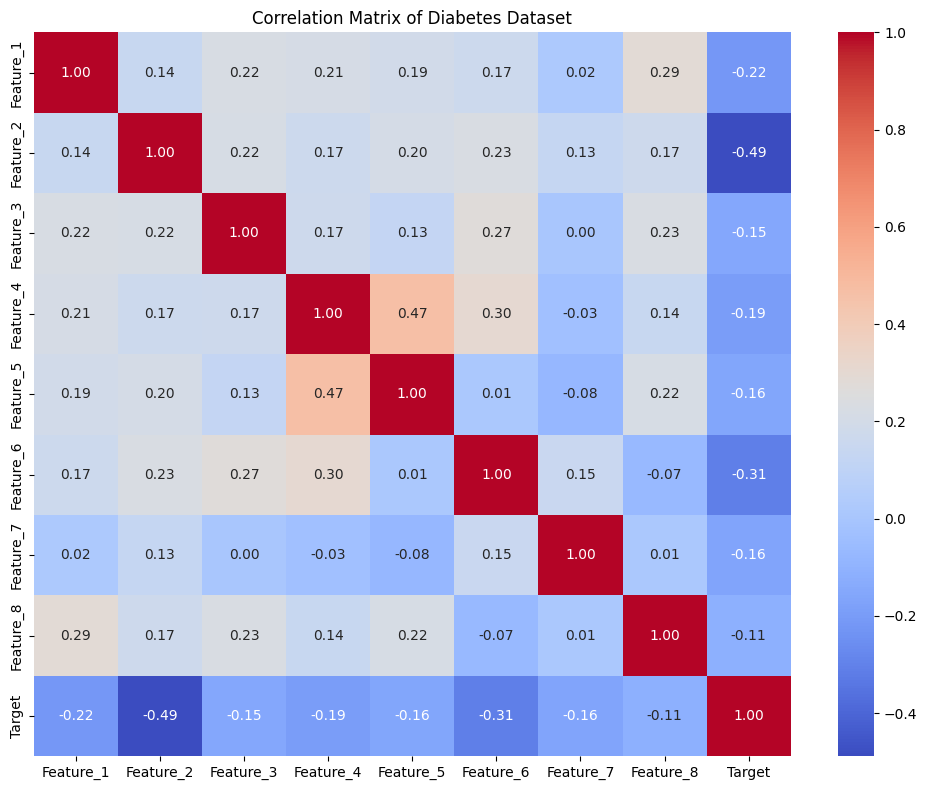

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Diabetes Dataset")
plt.tight_layout()
plt.show()

### Observation

The correlation matrix shows that some input features have stronger linear relationships with the target than others. Feature_2 shows one of the strongest relationships with the target, while Feature_6 also has a noticeable relationship.

Several other features have weaker individual correlations. However, a weak individual correlation does not necessarily mean that a feature is useless because the neural network can learn combinations and non-linear relationships between multiple features.

## 2.8 Feature Distributions

Next, I will visualize the distribution of each input feature. This helps me understand how the feature values are spread across the dataset and whether some features have noticeably different distributions.

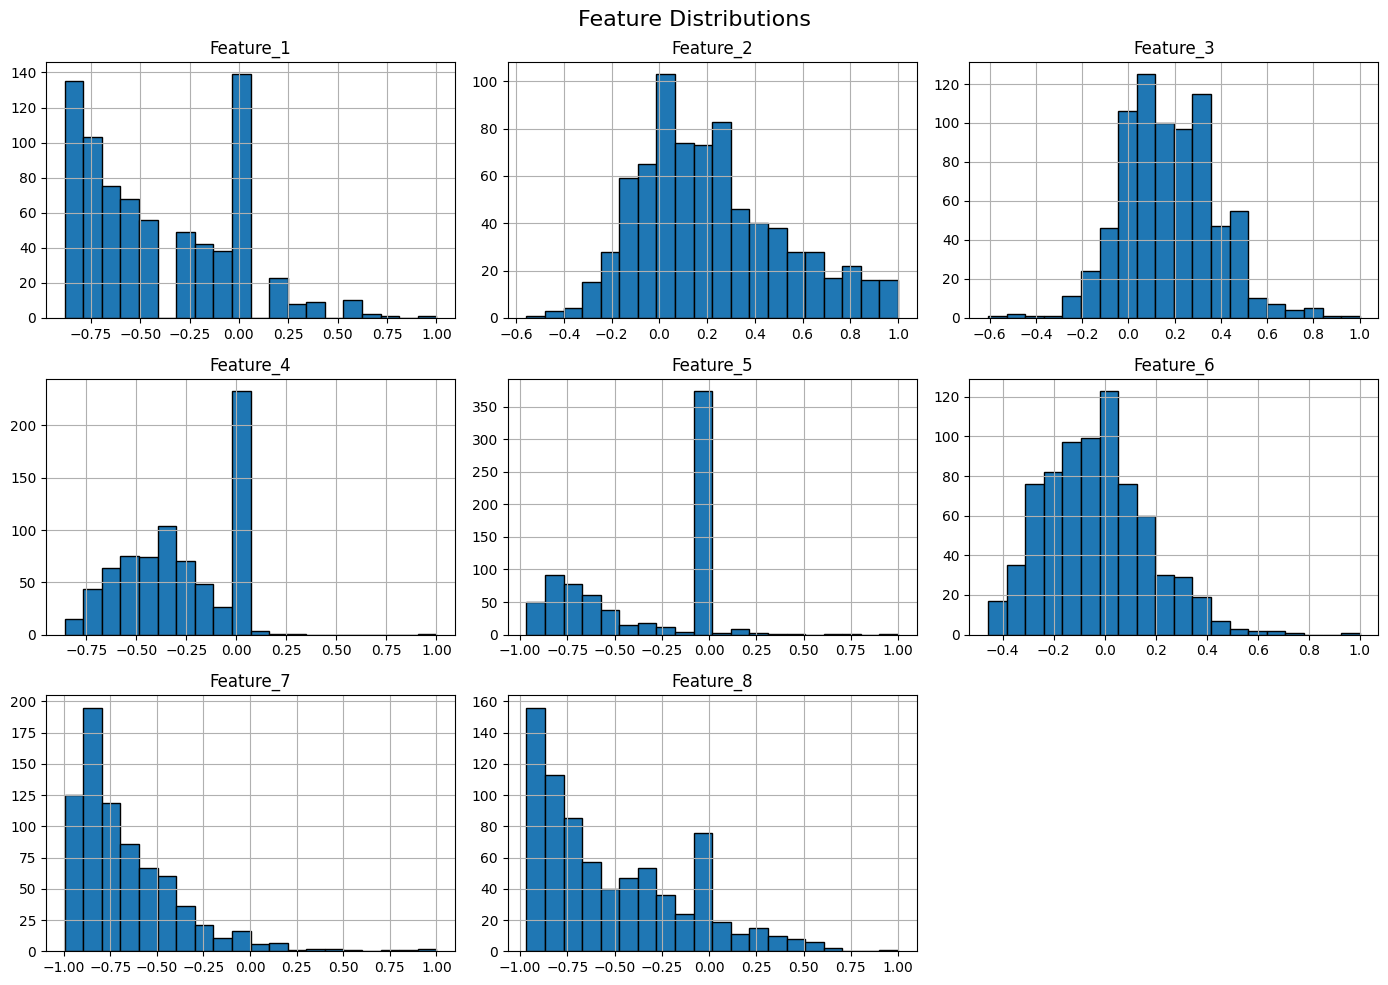

In [ ]:
# Plot distributions of the eight input features

feature_columns = [
    "Feature_1",
    "Feature_2",
    "Feature_3",
    "Feature_4",
    "Feature_5",
    "Feature_6",
    "Feature_7",
    "Feature_8"
]

df[feature_columns].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

The eight input features do not all have the same distribution. Some features are concentrated around particular values, while others are more spread out or skewed.

The statistical summary also shows that the feature values are already within a similar normalized numerical range. Therefore, I will use the provided values directly rather than applying an additional scaling transformation.

## 2.9 Preparing the Features and Target

The dataset contains eight input features and one target column. I will separate the input features from the target variable before creating the training, validation, and testing sets.

From the statistical summary, the provided feature values are already normalized to a similar numerical range. Therefore, I will use the provided normalized values instead of applying another scaling transformation.

In [ ]:
# Separate the input features and target

X = df.drop(columns=["Target"])
y = df["Target"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (759, 8)
Target data shape: (759,)


## 2.10 Training, Validation, and Testing Split

The assignment requires the dataset to be divided into 70% training data, 15% validation data, and 15% testing data using `random_state = SEED`.

I will first separate 70% of the data for training and keep the remaining 30% temporarily. I will then divide the remaining 30% equally into validation and testing sets.

I will create this split only once and reuse the same data for all PyTorch and TensorFlow experiments so that the model comparisons remain fair.

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% training and 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split: divide the remaining 30% equally
# 15% validation and 15% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (531, 8) (531,)
Validation set: (114, 8) (114,)
Testing set: (114, 8) (114,)


### 2.11 Verifying the Dataset Split

I will verify the number of samples in each subset and calculate their percentages to confirm that the required 70/15/15 split was created correctly.

In [ ]:
total_samples = len(df)

train_percent = len(X_train) / total_samples * 100
val_percent = len(X_val) / total_samples * 100
test_percent = len(X_test) / total_samples * 100

print("Total samples:", total_samples)

print(f"Training samples: {len(X_train)} ({train_percent:.2f}%)")
print(f"Validation samples: {len(X_val)} ({val_percent:.2f}%)")
print(f"Testing samples: {len(X_test)} ({test_percent:.2f}%)")

Total samples: 759
Training samples: 531 (69.96%)
Validation samples: 114 (15.02%)
Testing samples: 114 (15.02%)


### 2.12 Class Distribution After Splitting

Since the original dataset contains more samples from class 1 than class 0, I used stratified splitting to keep approximately the same class distribution in the training, validation, and testing subsets.

In [ ]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training class distribution:
Target
0    0.346516
1    0.653484
Name: proportion, dtype: float64

Validation class distribution:
Target
0    0.342105
1    0.657895
Name: proportion, dtype: float64

Testing class distribution:
Target
0    0.350877
1    0.649123
Name: proportion, dtype: float64


## 2.13 Converting the Data to PyTorch Tensors

PyTorch neural networks work with tensors instead of Pandas DataFrames. Therefore, I will convert the fixed training, validation, and testing datasets into PyTorch tensors.

I will use `float32` for both the input features and target values because neural network calculations are performed using floating-point values.

In [ ]:
# Convert the fixed data splits into PyTorch tensors

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_val:", X_val_tensor.shape)
print("y_val:", y_val_tensor.shape)

print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([531, 8])
y_train: torch.Size([531, 1])
X_val: torch.Size([114, 8])
y_val: torch.Size([114, 1])
X_test: torch.Size([114, 8])
y_test: torch.Size([114, 1])


### Observation

The training input tensor contains 531 samples with 8 features per sample. The target tensor contains one binary class value for each sample. The validation and testing sets were also converted using the same tensor format.

## 2.14 Selecting the Computation Device

Since the current Colab runtime has CUDA available, I will use the GPU for PyTorch model training. If CUDA is not available in another environment, the same code can fall back to the CPU.

In [ ]:
# Select GPU if it is available

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device being used:", device)

Device being used: cuda


## 2.15 Understanding the Baseline Neural Network Architecture

The baseline model required in this assignment uses two hidden layers with 64 and 32 neurons.

My dataset has 8 input features, so the neural network will take 8 values as input for each sample. The first hidden layer will contain 64 neurons, the second hidden layer will contain 32 neurons, and the final output layer will contain 1 neuron because this is a binary classification problem.

The overall architecture is:

**8 input features → 64 neurons → ReLU → 32 neurons → ReLU → 1 output**

The ReLU activation function is used after each hidden layer to introduce non-linearity, which allows the neural network to learn more complex relationships in the data.

### Architecture Flow

- **Input layer:** 8 features
- **Hidden layer 1:** 64 neurons
- **Activation:** ReLU
- **Hidden layer 2:** 32 neurons
- **Activation:** ReLU
- **Output layer:** 1 neuron

The output neuron will later be used to predict whether the sample belongs to class 0 or class 1.

## 2.16 PyTorch Feedforward Neural Network

I will define a feedforward neural network with two hidden layers containing 64 and 32 neurons, as required for the baseline model.

ReLU activation is used after each hidden layer to introduce non-linearity. The final layer contains one output because the target is a binary classification value.

In [ ]:

# Define the feedforward neural network
class DiabetesNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(8, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)

        return x

## 2.17 Baseline PyTorch Configuration

According to the assignment, the baseline model uses hidden layers [64, 32], a learning rate of 0.001, and 30 training epochs. I will use these settings without changing them so that the later modified model can be compared fairly.

In [ ]:
# Baseline settings required by the assignment

BASELINE_LR = 0.001
BASELINE_EPOCHS = 30

print("Baseline hidden layers: [64, 32]")
print("Baseline learning rate:", BASELINE_LR)
print("Baseline epochs:", BASELINE_EPOCHS)

Baseline hidden layers: [64, 32]
Baseline learning rate: 0.001
Baseline epochs: 30


## 2.18 Loss Function and Optimizer

To train the neural network, I need a loss function to measure how far the model predictions are from the true target values and an optimizer to update the model parameters.

Since this is a binary classification problem, I will use `BCEWithLogitsLoss`. This loss function is suitable for a single output neuron and internally applies the sigmoid operation when calculating the binary cross-entropy loss.

For optimization, I will use the Adam optimizer with the baseline learning rate of 0.001. During training, the optimizer will use the gradients calculated through backpropagation to update the weights and biases of the network.

In [ ]:
# Loss function for binary classification
loss_function = nn.BCEWithLogitsLoss()

# Adam optimizer will be created after the model is initialized
print("Loss function: BCEWithLogitsLoss")
print("Optimizer: Adam")
print("Learning rate:", BASELINE_LR)

Loss function: BCEWithLogitsLoss
Optimizer: Adam
Learning rate: 0.001


## 2.19 PyTorch Training Function

I will now create a training function that can be reused for the baseline and modified PyTorch models.

For each training run, I will first set the training seed and then initialize a new neural network. This is important because the initial weights of a neural network are random, and the assignment later requires me to repeat training using SEED, SEED+1, and SEED+2.

During every epoch, the model will make predictions on the training data, calculate the loss, perform backpropagation, and update its weights using the Adam optimizer. I will also calculate the validation loss after each epoch so that I can compare the training and validation behavior later.

In [ ]:
# Function to train a PyTorch model

def train_pytorch_model(learning_rate, epochs, training_seed):

    # Set the seed before creating the model
    random.seed(training_seed)
    np.random.seed(training_seed)
    torch.manual_seed(training_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(training_seed)

    # Create a new model for this training run
    model = DiabetesNN().to(device)

    # Loss function
    criterion = nn.BCEWithLogitsLoss()

    # Adam optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # Move the data to the selected device
    X_tr = X_train_tensor.to(device)
    y_tr = y_train_tensor.to(device)

    X_va = X_val_tensor.to(device)
    y_va = y_val_tensor.to(device)

    # Store losses for every epoch
    training_losses = []
    validation_losses = []

    for epoch in range(epochs):

        # --------------------
        # Training
        # --------------------
        model.train()

        optimizer.zero_grad()

        train_output = model(X_tr)

        train_loss = criterion(
            train_output,
            y_tr
        )

        train_loss.backward()

        optimizer.step()

        # --------------------
        # Validation
        # --------------------
        model.eval()

        with torch.no_grad():

            val_output = model(X_va)

            val_loss = criterion(
                val_output,
                y_va
            )

        training_losses.append(train_loss.item())
        validation_losses.append(val_loss.item())

    return model, training_losses, validation_losses

## 2.20 PyTorch Baseline Model - SEED Run

I will now train the baseline PyTorch model using my assigned SEED value of 1598.

The baseline configuration required by the assignment is:

- Hidden layers: [64, 32]
- Learning rate: 0.001
- Epochs: 30
- Training seed: 1598

I will save the training and validation losses from this run so that I can later plot the required loss curves.

In [ ]:
# Train the PyTorch baseline model

pytorch_baseline_model, baseline_train_losses, baseline_val_losses = train_pytorch_model(
    learning_rate=BASELINE_LR,
    epochs=BASELINE_EPOCHS,
    training_seed=SEED
)

print("PyTorch baseline training completed.")

print("Final training loss:", round(baseline_train_losses[-1], 4))
print("Final validation loss:", round(baseline_val_losses[-1], 4))

PyTorch baseline training completed.
Final training loss: 0.6359
Final validation loss: 0.6385


## 2.21 Evaluating the PyTorch Baseline Model

After training the baseline model, I will evaluate it using the testing set. The testing data was not used to update the model weights, so it provides a better estimate of how the trained model performs on unseen samples.

The neural network produces raw output values called logits. I will apply the sigmoid function to convert these values into probabilities between 0 and 1. A probability of 0.5 or greater will be classified as class 1, while a value below 0.5 will be classified as class 0.

I will use accuracy as the evaluation metric and use the same metric later for all PyTorch and TensorFlow model comparisons.

In [ ]:
# Evaluate the PyTorch baseline model on the test set

pytorch_baseline_model.eval()

X_te = X_test_tensor.to(device)
y_te = y_test_tensor.to(device)

with torch.no_grad():

    # Raw model output
    test_logits = pytorch_baseline_model(X_te)

    # Convert logits into probabilities
    test_probabilities = torch.sigmoid(test_logits)

    # Convert probabilities into class predictions
    test_predictions = (test_probabilities >= 0.5).float()

    # Calculate accuracy
    baseline_test_accuracy = (
        test_predictions == y_te
    ).float().mean().item()

print(
    "PyTorch baseline test accuracy:",
    round(baseline_test_accuracy, 4)
)

print(
    "PyTorch baseline test accuracy (%):",
    round(baseline_test_accuracy * 100, 2)
)

PyTorch baseline test accuracy: 0.6579
PyTorch baseline test accuracy (%): 65.79


### Observation

The baseline PyTorch model completed 30 epochs with a final training loss of 0.6359 and a final validation loss of 0.6385.

On the unseen testing set, the model achieved a test accuracy of 65.79 %. This result will be used as the baseline when I compare it with my HP_ID = 2 modified model.

### Checking the Baseline Prediction Distribution

The baseline test accuracy is 65.79%, which is close to the percentage of class 1 samples in the dataset. Because of this, I want to check how many class 0 and class 1 predictions the model is making.

This check helps me understand whether the model is learning both classes or mainly predicting the majority class.

In [ ]:
# Check how many samples were predicted as each class

predicted_class_0 = (test_predictions == 0).sum().item()
predicted_class_1 = (test_predictions == 1).sum().item()

actual_class_0 = (y_te == 0).sum().item()
actual_class_1 = (y_te == 1).sum().item()

print("Predicted class 0:", predicted_class_0)
print("Predicted class 1:", predicted_class_1)

print("\nActual class 0:", actual_class_0)
print("Actual class 1:", actual_class_1)

Predicted class 0: 1
Predicted class 1: 113

Actual class 0: 40
Actual class 1: 74


### Observation

The baseline PyTorch model predicted class 1 for 113 out of 114 test samples, even though only 74 test samples actually belong to class 1.

This means that the baseline model is mostly predicting the majority class instead of learning to separate both classes. Predicting only the majority class would already give approximately 64.91% accuracy on this test set, which is very close to the baseline test accuracy of 65.79%.

Therefore, the baseline PyTorch model appears to be underfitting, and the accuracy value alone does not fully describe its behavior.

## 2.22 HP_ID Modified PyTorch Model

My assigned HP_ID is 2. According to the HW1 configuration, the modified model must use a higher learning rate of 0.003.

The architecture and number of epochs remain unchanged so that the main difference between the baseline and modified models is the learning rate.

### Modified Configuration

- Hidden layers: [64, 32]
- Learning rate: 0.003
- Epochs: 30
- Training seed: 1598

I will use the same training, validation, and testing data as the baseline model so that the comparison is fair.

In [ ]:
# Modified settings for HP_ID = 2

MODIFIED_LR = 0.003
MODIFIED_EPOCHS = 30

print("HP_ID:", HP_ID)
print("Modified hidden layers: [64, 32]")
print("Modified learning rate:", MODIFIED_LR)
print("Modified epochs:", MODIFIED_EPOCHS)

HP_ID: 2
Modified hidden layers: [64, 32]
Modified learning rate: 0.003
Modified epochs: 30


## 2.23 Training the Modified PyTorch Model - SEED Run

I will now train the HP_ID modified PyTorch model using the same training seed of 1598.

Using the same seed and the same dataset split allows me to compare the effect of increasing the learning rate from 0.001 to 0.003 while keeping the other settings unchanged.

In [ ]:
# Train the modified PyTorch model

pytorch_modified_model, modified_train_losses, modified_val_losses = train_pytorch_model(
    learning_rate=MODIFIED_LR,
    epochs=MODIFIED_EPOCHS,
    training_seed=SEED
)

print("PyTorch modified model training completed.")

print(
    "Final training loss:",
    round(modified_train_losses[-1], 4)
)

print(
    "Final validation loss:",
    round(modified_val_losses[-1], 4)
)

PyTorch modified model training completed.
Final training loss: 0.5117
Final validation loss: 0.5177


## 2.24 Evaluating the Modified PyTorch Model

I will evaluate the modified model on the same testing set used for the baseline model. I will again use accuracy as the evaluation metric so that the comparison between the two models remains consistent.

In [ ]:
# Evaluate the modified model on the test set

pytorch_modified_model.eval()

with torch.no_grad():

    modified_test_logits = pytorch_modified_model(X_te)

    modified_test_probabilities = torch.sigmoid(
        modified_test_logits
    )

    modified_test_predictions = (
        modified_test_probabilities >= 0.5
    ).float()

    modified_test_accuracy = (
        modified_test_predictions == y_te
    ).float().mean().item()

print(
    "PyTorch modified test accuracy:",
    round(modified_test_accuracy, 4)
)

print(
    "PyTorch modified test accuracy (%):",
    round(modified_test_accuracy * 100, 2)
)

PyTorch modified test accuracy: 0.7544
PyTorch modified test accuracy (%): 75.44


In [ ]:
print("PyTorch Baseline")
print("Learning rate:", BASELINE_LR)
print("Test accuracy:", round(baseline_test_accuracy * 100, 2), "%")

print("\nPyTorch Modified")
print("Learning rate:", MODIFIED_LR)
print("Test accuracy:", round(modified_test_accuracy * 100, 2), "%")

PyTorch Baseline
Learning rate: 0.001
Test accuracy: 65.79 %

PyTorch Modified
Learning rate: 0.003
Test accuracy: 75.44 %


## 2.25 PyTorch Training and Validation Loss Curves

For the SEED = 1598 run, I will compare the training and validation loss of the baseline and modified PyTorch models across all epochs.

These curves help me understand how the two learning rates affect training behavior. I will look at whether the losses decrease smoothly and whether there is a noticeable gap between training and validation loss that could indicate overfitting or underfitting.

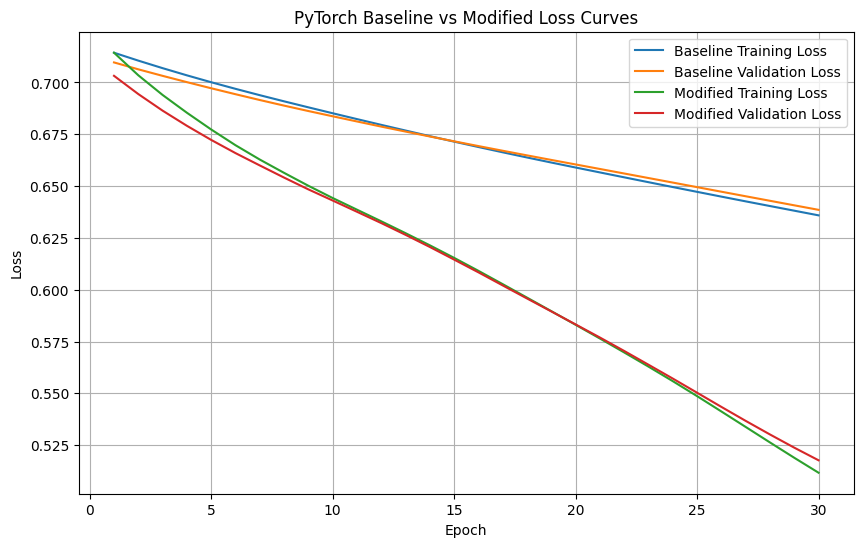

In [ ]:
# Plot training and validation loss for baseline and modified models

epochs = range(1, BASELINE_EPOCHS + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_train_losses,
    label="Baseline Training Loss"
)

plt.plot(
    epochs,
    baseline_val_losses,
    label="Baseline Validation Loss"
)

plt.plot(
    epochs,
    modified_train_losses,
    label="Modified Training Loss"
)

plt.plot(
    epochs,
    modified_val_losses,
    label="Modified Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch Baseline vs Modified Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

### Observation

The modified PyTorch model learns faster than the baseline model. Both its training loss and validation loss decrease more quickly and reach lower values by the end of the 30 epochs.

The modified validation loss continues to decrease throughout training and stays close to the training loss. Therefore, there is no clear evidence of overfitting during these 30 epochs.

The baseline model improves much more slowly, and its prediction analysis showed that it classified almost all test samples as class 1. This suggests that the baseline model is underfitting, while the higher learning rate helped the modified model learn more effectively.

## 2.26 PyTorch Three-Seed Experiment

The assignment requires the baseline and modified models to be trained three times using SEED, SEED+1, and SEED+2.

I will keep the training, validation, and testing split unchanged. Only the training seed will change between runs. This allows me to check whether the model performance is stable across different random weight initializations.

In [ ]:
# Function to calculate PyTorch test accuracy

def evaluate_pytorch_model(model):

    model.eval()

    with torch.no_grad():

        logits = model(X_te)

        probabilities = torch.sigmoid(logits)

        predictions = (probabilities >= 0.5).float()

        accuracy = (
            predictions == y_te
        ).float().mean().item()

    return accuracy

## 2.27 Running the Three PyTorch Experiments

I will now train both configurations using the three required training seeds. For every run, I will calculate the test accuracy and store the result for the final comparison.

In [ ]:
# Required training seeds
training_seeds = [SEED, SEED + 1, SEED + 2]

baseline_accuracies = []
modified_accuracies = []

for current_seed in training_seeds:

    # -----------------------------
    # Baseline model
    # -----------------------------
    baseline_model, _, _ = train_pytorch_model(
        learning_rate=BASELINE_LR,
        epochs=BASELINE_EPOCHS,
        training_seed=current_seed
    )

    baseline_accuracy = evaluate_pytorch_model(
        baseline_model
    )

    baseline_accuracies.append(
        baseline_accuracy
    )

    # -----------------------------
    # Modified model
    # -----------------------------
    modified_model, _, _ = train_pytorch_model(
        learning_rate=MODIFIED_LR,
        epochs=MODIFIED_EPOCHS,
        training_seed=current_seed
    )

    modified_accuracy = evaluate_pytorch_model(
        modified_model
    )

    modified_accuracies.append(
        modified_accuracy
    )

    print(
        "Seed:", current_seed,
        "| Baseline:", round(baseline_accuracy * 100, 2), "%",
        "| Modified:", round(modified_accuracy * 100, 2), "%"
    )

Seed: 1598 | Baseline: 65.79 % | Modified: 75.44 %
Seed: 1599 | Baseline: 65.79 % | Modified: 73.68 %
Seed: 1600 | Baseline: 64.91 % | Modified: 71.93 %


## 2.28 PyTorch Mean and Standard Deviation

After completing the three training runs, I will calculate the mean test accuracy and standard deviation for both configurations.

The mean gives the average performance across the three runs, while the standard deviation shows how much the accuracy changes between different training seeds.

In [ ]:
# Convert accuracies to percentages

baseline_percentages = np.array(baseline_accuracies) * 100
modified_percentages = np.array(modified_accuracies) * 100

# Calculate mean and standard deviation
baseline_mean = np.mean(baseline_percentages)
baseline_std = np.std(baseline_percentages)

modified_mean = np.mean(modified_percentages)
modified_std = np.std(modified_percentages)

print("PyTorch Baseline")
print("Mean test accuracy:", round(baseline_mean, 2), "%")
print("Standard deviation:", round(baseline_std, 2))

print("\nPyTorch Modified")
print("Mean test accuracy:", round(modified_mean, 2), "%")
print("Standard deviation:", round(modified_std, 2))

PyTorch Baseline
Mean test accuracy: 65.5 %
Standard deviation: 0.41

PyTorch Modified
Mean test accuracy: 73.68 %
Standard deviation: 1.43


In [ ]:
pytorch_results = pd.DataFrame({
    "Model": ["Baseline", "Modified"],
    "Learning Rate": [BASELINE_LR, MODIFIED_LR],
    "Mean Test Accuracy (%)": [
        round(baseline_mean, 2),
        round(modified_mean, 2)
    ],
    "Standard Deviation": [
        round(baseline_std, 2),
        round(modified_std, 2)
    ]
})

pytorch_results

,Model,Learning Rate,Mean Test Accuracy (%),Standard Deviation
0,Baseline,0.001,65.50,0.41
1,Modified,0.003,73.68,1.43


## 2.29 PyTorch Results Checkpoint

I have now completed the baseline and HP_ID-modified PyTorch experiments.

The baseline model uses a learning rate of 0.001, while my HP_ID = 2 modified model uses a learning rate of 0.003. Both models use the same hidden layers [64, 32], the same 30 epochs, and the same fixed training, validation, and testing split.

The final PyTorch conclusion will be written after comparing the loss curves and the mean and standard deviation from all three training seeds.

# 2.30 TensorFlow Neural Network Implementation

I will now implement the same neural network experiment using TensorFlow/Keras.

To make the comparison with PyTorch fair, I will use the same eight input features, the same fixed training, validation, and testing split, the same hidden-layer architecture [64, 32], and accuracy as the evaluation metric.

The baseline TensorFlow model will use a learning rate of 0.001 for 30 epochs. My HP_ID = 2 modified TensorFlow model will keep the same architecture and number of epochs but will use a higher learning rate of 0.003.

## 2.31 Preparing Data for TensorFlow

Before building the TensorFlow model, I will convert the same fixed training, validation, and testing sets into NumPy arrays with float32 data type.

I am using the same data split that was already created for PyTorch instead of creating a new split. This keeps the comparison between PyTorch and TensorFlow consistent.

In [ ]:
# Convert the existing fixed splits to NumPy arrays

X_train_tf = X_train.to_numpy(dtype=np.float32)
X_val_tf = X_val.to_numpy(dtype=np.float32)
X_test_tf = X_test.to_numpy(dtype=np.float32)

y_train_tf = y_train.to_numpy(dtype=np.float32)
y_val_tf = y_val.to_numpy(dtype=np.float32)
y_test_tf = y_test.to_numpy(dtype=np.float32)

print("X_train:", X_train_tf.shape)
print("y_train:", y_train_tf.shape)

print("X_val:", X_val_tf.shape)
print("y_val:", y_val_tf.shape)

print("X_test:", X_test_tf.shape)
print("y_test:", y_test_tf.shape)

X_train: (531, 8)
y_train: (531,)
X_val: (114, 8)
y_val: (114,)
X_test: (114, 8)
y_test: (114,)


## 2.32 TensorFlow Feedforward Neural Network

I will create the TensorFlow model using the Keras Sequential API.

The model has the same architecture used in the PyTorch baseline:

**8 input features → 64 neurons → ReLU → 32 neurons → ReLU → 1 output**

Since this is a binary classification problem, the final neuron uses a sigmoid activation so that the output is a probability between 0 and 1.

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

def create_tensorflow_model(learning_rate, training_seed):

    # Clear any model left from a previous run
    tf.keras.backend.clear_session()

    # Set seed before creating the model
    tf.keras.utils.set_random_seed(training_seed)

    model = Sequential([
        Input(shape=(8,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    optimizer = Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 2.33 TensorFlow Baseline Configuration

The TensorFlow baseline will use the exact settings required by the assignment:

- Hidden layers: [64, 32]
- Learning rate: 0.001
- Epochs: 30
- Evaluation metric: Accuracy
- Training seed: 1598

The same validation and testing sets used for PyTorch will also be used here.

In [ ]:
TF_BASELINE_LR = 0.001
TF_BASELINE_EPOCHS = 30

print("TensorFlow baseline hidden layers: [64, 32]")
print("TensorFlow baseline learning rate:", TF_BASELINE_LR)
print("TensorFlow baseline epochs:", TF_BASELINE_EPOCHS)

TensorFlow baseline hidden layers: [64, 32]
TensorFlow baseline learning rate: 0.001
TensorFlow baseline epochs: 30


## 2.34 TensorFlow Baseline Model - SEED Run

I will now train the TensorFlow baseline model using SEED = 1598.

I will save the training history because the training and validation losses from this run will later be plotted and compared with the modified TensorFlow model.

In [ ]:
# Create the TensorFlow baseline model

tensorflow_baseline_model = create_tensorflow_model(
    learning_rate=TF_BASELINE_LR,
    training_seed=SEED
)

# Train the model

baseline_tf_history = tensorflow_baseline_model.fit(
    X_train_tf,
    y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=TF_BASELINE_EPOCHS,
    batch_size=32,
    verbose=0
)

print("TensorFlow baseline training completed.")

print(
    "Final training loss:",
    round(baseline_tf_history.history["loss"][-1], 4)
)

print(
    "Final validation loss:",
    round(baseline_tf_history.history["val_loss"][-1], 4)
)

TensorFlow baseline training completed.
Final training loss: 0.414
Final validation loss: 0.4771


## 2.35 Evaluating the TensorFlow Baseline Model

I will evaluate the TensorFlow baseline model using the same unseen testing set.

Accuracy is used again so that the TensorFlow results can later be compared with the PyTorch results using the same evaluation metric.

In [ ]:
baseline_tf_loss, baseline_tf_accuracy = tensorflow_baseline_model.evaluate(
    X_test_tf,
    y_test_tf,
    verbose=0
)

print(
    "TensorFlow baseline test accuracy:",
    round(baseline_tf_accuracy, 4)
)

print(
    "TensorFlow baseline test accuracy (%):",
    round(baseline_tf_accuracy * 100, 2)
)

TensorFlow baseline test accuracy: 0.7368
TensorFlow baseline test accuracy (%): 73.68


## 2.36 TensorFlow Modified Configuration

My assigned HP_ID is 2. According to the assignment, the modified model must use the same hidden-layer architecture [64, 32] and the same 30 training epochs as the baseline model, but the learning rate must be increased from 0.001 to 0.003.

This allows me to study how a higher learning rate affects the training behavior and test performance while keeping the rest of the model unchanged.

In [ ]:
# Modified TensorFlow settings for HP_ID = 2

TF_MODIFIED_LR = 0.003
TF_MODIFIED_EPOCHS = 30

print("HP_ID:", HP_ID)
print("Modified hidden layers: [64, 32]")
print("Modified learning rate:", TF_MODIFIED_LR)
print("Modified epochs:", TF_MODIFIED_EPOCHS)

HP_ID: 2
Modified hidden layers: [64, 32]
Modified learning rate: 0.003
Modified epochs: 30


## 2.37 TensorFlow Modified Model - SEED Run

I will now train the modified TensorFlow model using the same training seed of 1598 and the same fixed training and validation data used for the baseline model.

The only change is the learning rate, which is increased from 0.001 to 0.003.

In [ ]:
# Create the modified TensorFlow model

tensorflow_modified_model = create_tensorflow_model(
    learning_rate=TF_MODIFIED_LR,
    training_seed=SEED
)

# Train the modified model

modified_tf_history = tensorflow_modified_model.fit(
    X_train_tf,
    y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=TF_MODIFIED_EPOCHS,
    batch_size=32,
    verbose=0
)

print("TensorFlow modified training completed.")

print(
    "Final training loss:",
    round(modified_tf_history.history["loss"][-1], 4)
)

print(
    "Final validation loss:",
    round(modified_tf_history.history["val_loss"][-1], 4)
)

TensorFlow modified training completed.
Final training loss: 0.3604
Final validation loss: 0.4569


## 2.38 Evaluating the TensorFlow Modified Model

I will evaluate the modified TensorFlow model on the same unseen testing set used for the baseline model.

Accuracy will again be used as the evaluation metric so that the comparison remains consistent.

In [ ]:
modified_tf_loss, modified_tf_accuracy = tensorflow_modified_model.evaluate(
    X_test_tf,
    y_test_tf,
    verbose=0
)

print(
    "TensorFlow modified test accuracy:",
    round(modified_tf_accuracy, 4)
)

print(
    "TensorFlow modified test accuracy (%):",
    round(modified_tf_accuracy * 100, 2)
)

TensorFlow modified test accuracy: 0.7368
TensorFlow modified test accuracy (%): 73.68


## 2.39 TensorFlow Baseline vs Modified - SEED Run

I will first compare the baseline and modified TensorFlow results for the SEED = 1598 run.

This is only an initial comparison. The final conclusion will be based on the required three-seed experiment and the loss curves.

In [ ]:
print("TensorFlow Baseline")
print("Learning rate:", TF_BASELINE_LR)
print(
    "Test accuracy:",
    round(baseline_tf_accuracy * 100, 2),
    "%"
)

print("\nTensorFlow Modified")
print("Learning rate:", TF_MODIFIED_LR)
print(
    "Test accuracy:",
    round(modified_tf_accuracy * 100, 2),
    "%"
)

TensorFlow Baseline
Learning rate: 0.001
Test accuracy: 73.68 %

TensorFlow Modified
Learning rate: 0.003
Test accuracy: 73.68 %


## 2.40 TensorFlow Training and Validation Loss Curves

For the SEED = 1598 run, I will plot the training and validation losses of both TensorFlow models on the same figure.

These curves will help me compare how the baseline learning rate of 0.001 and the modified learning rate of 0.003 affect convergence and whether either model shows signs of overfitting or underfitting.

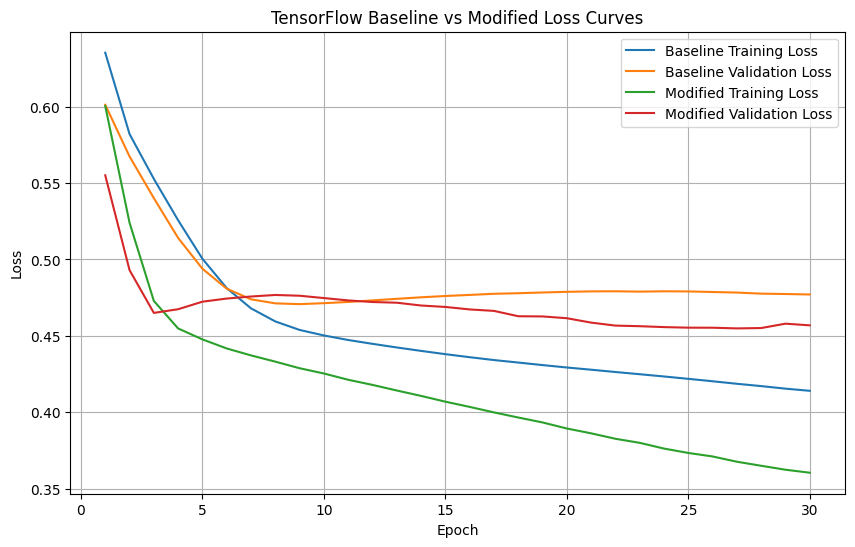

In [ ]:
tf_epochs = range(1, TF_BASELINE_EPOCHS + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    tf_epochs,
    baseline_tf_history.history["loss"],
    label="Baseline Training Loss"
)

plt.plot(
    tf_epochs,
    baseline_tf_history.history["val_loss"],
    label="Baseline Validation Loss"
)

plt.plot(
    tf_epochs,
    modified_tf_history.history["loss"],
    label="Modified Training Loss"
)

plt.plot(
    tf_epochs,
    modified_tf_history.history["val_loss"],
    label="Modified Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow Baseline vs Modified Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

### Observation

The modified TensorFlow model reduces the training loss faster than the baseline model, and its validation loss is lower during most of the later epochs.

However, for SEED = 1598, both models achieved the same test accuracy of 73.68%. Therefore, the two models are indistinguishable in test accuracy for this particular run, even though the modified model shows faster convergence and lower loss.

Toward the later epochs, the modified training loss continues to decrease while its validation loss becomes nearly flat. This suggests a mild tendency toward overfitting, but the validation loss does not increase sharply.

## 2.41 TensorFlow Three-Seed Experiment

The assignment requires both the baseline and modified models to be trained using three different training seeds: SEED, SEED+1, and SEED+2.

I will keep the training, validation, and testing split unchanged. Only the model training seed will change. This helps me check whether the model performance is consistent across different random weight initializations.

In [ ]:
# Required training seeds
tf_training_seeds = [SEED, SEED + 1, SEED + 2]

tf_baseline_accuracies = []
tf_modified_accuracies = []

for current_seed in tf_training_seeds:

    # -----------------------------
    # Baseline TensorFlow model
    # -----------------------------
    baseline_model = create_tensorflow_model(
        learning_rate=TF_BASELINE_LR,
        training_seed=current_seed
    )

    baseline_history = baseline_model.fit(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        epochs=TF_BASELINE_EPOCHS,
        batch_size=32,
        verbose=0
    )

    _, baseline_accuracy = baseline_model.evaluate(
        X_test_tf,
        y_test_tf,
        verbose=0
    )

    tf_baseline_accuracies.append(baseline_accuracy)

    # -----------------------------
    # Modified TensorFlow model
    # -----------------------------
    modified_model = create_tensorflow_model(
        learning_rate=TF_MODIFIED_LR,
        training_seed=current_seed
    )

    modified_history = modified_model.fit(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        epochs=TF_MODIFIED_EPOCHS,
        batch_size=32,
        verbose=0
    )

    _, modified_accuracy = modified_model.evaluate(
        X_test_tf,
        y_test_tf,
        verbose=0
    )

    tf_modified_accuracies.append(modified_accuracy)

    print(
        "Seed:", current_seed,
        "| Baseline:", round(baseline_accuracy * 100, 2), "%",
        "| Modified:", round(modified_accuracy * 100, 2), "%"
    )

Seed: 1598 | Baseline: 73.68 % | Modified: 73.68 %
Seed: 1599 | Baseline: 71.05 % | Modified: 71.93 %
Seed: 1600 | Baseline: 71.05 % | Modified: 73.68 %


## 2.42 TensorFlow Mean and Standard Deviation

After completing the three TensorFlow training runs, I will calculate the mean test accuracy and standard deviation for the baseline and modified models.

The mean represents the average model performance, while the standard deviation shows how much the test accuracy changes across the three training seeds.

In [ ]:
# Convert accuracies to percentages
tf_baseline_percentages = np.array(tf_baseline_accuracies) * 100
tf_modified_percentages = np.array(tf_modified_accuracies) * 100

# Mean and standard deviation
tf_baseline_mean = np.mean(tf_baseline_percentages)
tf_baseline_std = np.std(tf_baseline_percentages)

tf_modified_mean = np.mean(tf_modified_percentages)
tf_modified_std = np.std(tf_modified_percentages)

print("TensorFlow Baseline")
print("Mean test accuracy:", round(tf_baseline_mean, 2), "%")
print("Standard deviation:", round(tf_baseline_std, 2))

print("\nTensorFlow Modified")
print("Mean test accuracy:", round(tf_modified_mean, 2), "%")
print("Standard deviation:", round(tf_modified_std, 2))

TensorFlow Baseline
Mean test accuracy: 71.93 %
Standard deviation: 1.24

TensorFlow Modified
Mean test accuracy: 73.1 %
Standard deviation: 0.83


In [ ]:
tensorflow_results = pd.DataFrame({
    "Model": ["Baseline", "Modified"],
    "Learning Rate": [
        TF_BASELINE_LR,
        TF_MODIFIED_LR
    ],
    "Mean Test Accuracy (%)": [
        round(tf_baseline_mean, 2),
        round(tf_modified_mean, 2)
    ],
    "Standard Deviation": [
        round(tf_baseline_std, 2),
        round(tf_modified_std, 2)
    ]
})

tensorflow_results

,Model,Learning Rate,Mean Test Accuracy (%),Standard Deviation
0,Baseline,0.001,71.93,1.24
1,Modified,0.003,73.10,0.83


### Observation

Across the three training seeds, the TensorFlow baseline model achieved a mean test accuracy of 71.93% with a standard deviation of 1.24.

The HP_ID = 2 modified model achieved a higher mean test accuracy of 73.10% with a lower standard deviation of 0.83. This means that increasing the learning rate from 0.001 to 0.003 produced a small improvement in average test accuracy and also gave slightly more consistent results across the three runs.

From the loss curves, the modified model learned faster and had a lower validation loss for most of the training. The training loss continued to decrease while the validation loss became nearly flat toward the later epochs, which suggests a small tendency toward overfitting, but it was not severe.

## 2.43 Final PyTorch and TensorFlow Comparison

I will now combine the results from both frameworks into one table.

All four experiments used the same fixed training, validation, and testing split and the same accuracy metric. The baseline models used a learning rate of 0.001, while my HP_ID = 2 modified models used a learning rate of 0.003.

In [ ]:

# Final comparison of all neural network experiments

final_results = pd.DataFrame({
    "Framework": [
        "PyTorch",
        "PyTorch",
        "TensorFlow",
        "TensorFlow"
    ],

    "Model": [
        "Baseline",
        "Modified",
        "Baseline",
        "Modified"
    ],

    "Learning Rate": [
        BASELINE_LR,
        MODIFIED_LR,
        TF_BASELINE_LR,
        TF_MODIFIED_LR
    ],

    "Mean Test Accuracy (%)": [
        round(baseline_mean, 2),
        round(modified_mean, 2),
        round(tf_baseline_mean, 2),
        round(tf_modified_mean, 2)
    ],

    "Standard Deviation": [
        round(baseline_std, 2),
        round(modified_std, 2),
        round(tf_baseline_std, 2),
        round(tf_modified_std, 2)
    ]
})

final_results

,Framework,Model,Learning Rate,Mean Test Accuracy (%),Standard Deviation
0,PyTorch,Baseline,0.001,65.50,0.41
1,PyTorch,Modified,0.003,73.68,1.43
2,TensorFlow,Baseline,0.001,71.93,1.24
3,TensorFlow,Modified,0.003,73.10,0.83


## 2.44 Effect of the HP_ID Modification

To make the comparison clearer, I will calculate the difference in mean test accuracy between the baseline and modified model for each framework.

In [ ]:
# Calculate improvement in mean test accuracy

pytorch_improvement = modified_mean - baseline_mean

tensorflow_improvement = (
    tf_modified_mean - tf_baseline_mean
)

print(
    "PyTorch improvement:",
    round(pytorch_improvement, 2),
    "percentage points"
)

print(
    "TensorFlow improvement:",
    round(tensorflow_improvement, 2),
    "percentage points"
)

PyTorch improvement: 8.19 percentage points
TensorFlow improvement: 1.17 percentage points


## 2.45 Conclusion

My assigned HP_ID is 2, so the required modification was to increase the learning rate from 0.001 to 0.003 while keeping the hidden layers [64, 32] and the number of training epochs at 30.

For PyTorch, the baseline model achieved a mean test accuracy of 65.50%, while the modified model achieved 73.68%. This is an improvement of 8.19 percentage points. The baseline prediction analysis showed that it predicted almost every test sample as class 1, which indicates underfitting. Increasing the learning rate helped the modified model learn more effectively. However, the modified model had a higher standard deviation, which means its performance varied more across the three training seeds.

For TensorFlow, the baseline model achieved a mean test accuracy of 71.93%, while the modified model achieved 73.10%. This is an improvement of 1.17 percentage points. The modified model also had a lower standard deviation, which indicates slightly more consistent performance across the three runs. For the SEED = 1598 run, both the baseline and modified TensorFlow models achieved the same test accuracy of 73.68%, although the modified model learned faster and had a lower validation loss during most of the training.

Overall, increasing the learning rate from 0.001 to 0.003 improved the average test accuracy in both frameworks. The improvement was much larger in PyTorch than in TensorFlow. The TensorFlow loss curves show a small tendency toward overfitting near the later epochs, but the validation loss does not increase sharply.